<a href="https://colab.research.google.com/github/BPerkins98/homework/blob/main/homework6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_

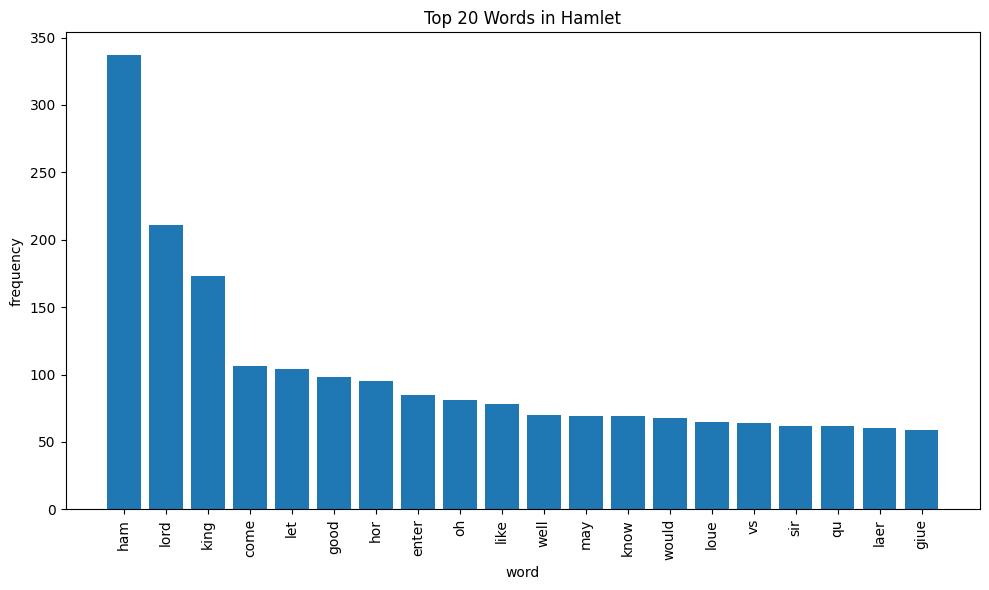

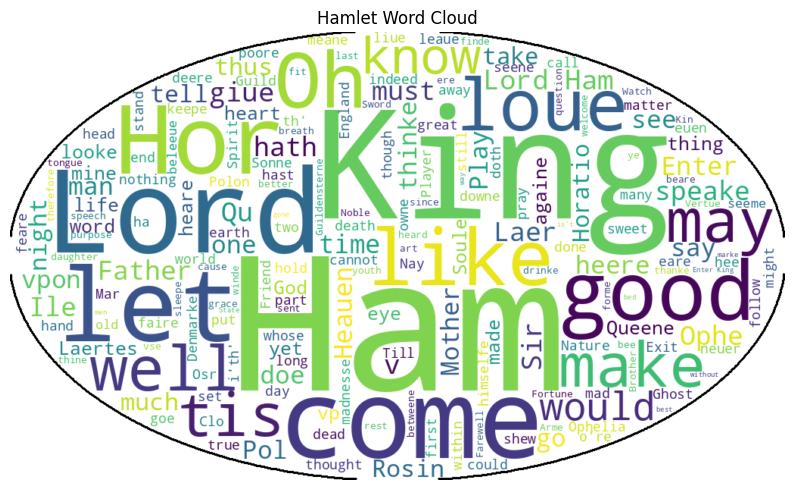

In [3]:
# Exercise 12.6 — Hamlet Word Cloud and Frequency Chart
# ------------------------------------------------------

# Install required packages
!pip install requests textblob wordcloud imageio matplotlib nltk

# Import libraries
import nltk
import requests
from textblob import TextBlob
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud
import imageio
import matplotlib.pyplot as plt

# ------------------------------------------------------
# FIX: Download all required NLTK + TextBlob corpora
nltk.download('punkt')
nltk.download('punkt_tab')        # <-- REQUIRED for new NLTK versions
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# TextBlob corpora (fixes MissingCorpusError)
import textblob.download_corpora
textblob.download_corpora.download_all()

# ------------------------------------------------------
# Step 1: Get Hamlet text from Project Gutenberg
target_url = 'https://www.gutenberg.org/files/2265/2265-0.txt'
response = requests.get(target_url)
data = response.text

# ------------------------------------------------------
# Step 2: Create TextBlob object
blob = TextBlob(data)

# ------------------------------------------------------
# Step 3: Prepare stopwords
stop_words = set(stopwords.words('english'))
extra = {"hamlet", "thou", "thee", "thy", "shall", "haue", "selfe"}
stop_words.update(extra)

# ------------------------------------------------------
# Step 4: Word frequency analysis
words = [w.lower() for w in blob.words if w.isalpha() and w.lower() not in stop_words]
counts = Counter(words)
top_words = counts.most_common(20)

# Plot frequency chart
labels, values = zip(*top_words)
plt.figure(figsize=(10,6))
plt.bar(labels, values)
plt.xticks(rotation=90)
plt.xlabel("word")
plt.ylabel("frequency")
plt.title("Top 20 Words in Hamlet")
plt.tight_layout()
plt.savefig("output1.png")
plt.show()

# ------------------------------------------------------
# Step 5: Load mask image
image_file = "https://media.cheggcdn.com/media/216/21621ee5-e80f-47f3-9145-513f2229b390/phploeBuh.png"
mask_image = imageio.v3.imread(image_file)

# ------------------------------------------------------
# Step 6: Generate word cloud
wc = WordCloud(
    background_color="white",
    stopwords=stop_words,
    mask=mask_image,
    contour_width=2,
    contour_color='black'
)

wc.generate(data)

plt.figure(figsize=(10,10))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Hamlet Word Cloud")
plt.savefig("Hamlet.png")
plt.show()

